# Loan Amount Prediction: A Comparative Regression Study

## Phase 1: Business Understanding and Problem Definition

### Business Context

Financial institutions that process consumer and commercial loan applications face a
recurring analytical challenge: determining, before a final approval decision is issued,
what loan amount is appropriate for a given applicant profile. This is fundamentally a
regression problem rather than a classification problem, because the quantity of interest,
the loan amount, is continuous rather than categorical. A binary approve or reject label
tells a lender whether an application should proceed, but it does not tell an underwriter
how much credit exposure is reasonable given an applicant's income, existing assets,
dependents, and creditworthiness indicators. Estimating the loan amount directly supports
pre-qualification workflows, portfolio risk sizing, and automated decision support tools
that recommend a sanctioned amount rather than a simple yes or no outcome.

### Why Regression and Not Classification

The dataset used in this study, loan_approval_dataset.csv, was originally compiled to
support a binary approval classification task through the loan_status column. This
project deliberately reframes the objective as a regression task: the target variable is
loan_amount, a continuous numerical quantity expressed in monetary units. The loan_status
column is intentionally excluded from the feature set used for regression, because in a
realistic deployment scenario the approval decision is made after, or in conjunction with,
the determination of the loan amount, and including it would introduce target leakage and
would not reflect information available at the time an amount recommendation is required.

### Economic Rationale for Accurate Loan Amount Estimation

Underestimating an appropriate loan amount can result in lost business opportunity and
customer dissatisfaction, while overestimating it increases the institution's exposure to
default risk and capital loss. A regression model that closely approximates the historical
relationship between applicant attributes and the loan amount actually extended provides a
data-driven baseline that can be integrated into underwriting workflows, compared against
manual decisions, and audited for consistency across applicant segments.

### Candidate Modeling Approaches

Four regression algorithms are evaluated and compared in this notebook:

1. Linear Regression, a parametric baseline that assumes a linear relationship between
   the predictors and the target, offering high interpretability and low computational cost.
2. Decision Tree Regressor, a non-parametric, non-linear model that partitions the feature
   space into axis-aligned regions and predicts the mean target value within each region.
3. Random Forest Regressor, an ensemble of decision trees trained on bootstrapped samples
   and random feature subsets, which typically reduces variance relative to a single tree.
4. XGBoost Regressor, a gradient boosting ensemble that builds trees sequentially, each one
   correcting the residual errors of its predecessors, generally providing strong predictive
   performance on structured tabular data.

The notebook trains, tunes, and evaluates all four models using a consistent methodology,
compares them using multiple regression error metrics, and selects the best performing
model for production deployment through a Streamlit web application.

### Success Criteria

The primary evaluation metric is the coefficient of determination, R-squared, on a held-out
test set, supplemented by Mean Absolute Error, Mean Squared Error, Root Mean Squared Error,
and Mean Absolute Percentage Error. A higher R-squared combined with lower absolute error
metrics indicates a model that more accurately reconstructs the true loan amount from
applicant attributes.

## Phase 2: Environment Setup and Data Ingestion

Data ingestion is the first operational step of any machine learning pipeline. Before any
transformation or modeling can take place, the raw dataset must be located on disk, loaded
into memory in a structured tabular form, and validated for basic structural integrity,
including the number of records, the number of columns, the data types assigned to each
column, and the presence of an identifiable target variable. Robust path resolution logic
is implemented so that this notebook executes correctly whether it is run from within a
notebooks directory, in which case data is located one level up under data/raw, or from the
project root directory, in which case data is located directly under data/raw. Memory
profiling through df.info() additionally reveals the memory footprint of the dataset and
confirms that no unexpected object columns or excessive null values are present before
proceeding to deeper quality assessment.

In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

import matplotlib.pyplot as plt
import seaborn as sns

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("Warning: the xgboost package is not installed in this environment.")
    print("Install it with: pip install xgboost")

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

candidate_paths = [
    os.path.join("..", "data", "raw", "loan_approval_dataset.csv"),
    os.path.join("data", "raw", "loan_approval_dataset.csv"),
]

DATA_PATH = None
for candidate in candidate_paths:
    if os.path.exists(candidate):
        DATA_PATH = candidate
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not locate loan_approval_dataset.csv in ../data/raw/ or data/raw/. "
        "Please verify the dataset location."
    )

print("Dataset located at:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
df.columns = [column.strip() for column in df.columns]

print("Dataset dimensions (rows, columns):", df.shape)
print()
print("First 5 rows of the raw dataset:")
display(df.head())
print()
print("Structural summary of the raw dataset:")
df.info()

Dataset located at: ..\data\raw\loan_approval_dataset.csv
Dataset dimensions (rows, columns): (4269, 13)

First 5 rows of the raw dataset:


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected



Structural summary of the raw dataset:
<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   str  
 3   self_employed             4269 non-null   str  
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


## Phase 3: Data Quality Assessment and Cleaning

Raw tabular datasets frequently contain inconsistencies that are invisible at a superficial
glance but that materially affect downstream modeling if left uncorrected. This phase
inspects every column for missing values, verifies that there are no exact duplicate
records, strips leading and trailing whitespace from string valued columns (a common
artifact of comma separated files authored with inconsistent spacing), and removes
non-predictive administrative identifier columns. The loan_id column is a sequential
identifier with no predictive relationship to the loan amount and is therefore dropped to
prevent the model from learning spurious associations with record order.

In [2]:
print("Missing values per column:")
print(df.isnull().sum())
print()

duplicate_count = df.duplicated().sum()
print("Number of exact duplicate rows:", duplicate_count)
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicate rows removed. New shape:", df.shape)

string_columns = df.select_dtypes(include="object").columns.tolist()
for column in string_columns:
    df[column] = df[column].astype(str).str.strip()

print()
print("Categorical column unique values after whitespace normalization:")
for column in string_columns:
    print(column, "->", df[column].unique().tolist())

identifier_columns = ["loan_id"]
columns_to_drop = [column for column in identifier_columns if column in df.columns]
if columns_to_drop:
    df = df.drop(columns=columns_to_drop)
    print()
    print("Dropped non-predictive identifier columns:", columns_to_drop)

print()
print("Cleaned column schema:")
print(df.dtypes)

Missing values per column:
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

Number of exact duplicate rows: 0

Categorical column unique values after whitespace normalization:
education -> ['Graduate', 'Not Graduate']
self_employed -> ['No', 'Yes']
loan_status -> ['Approved', 'Rejected']

Dropped non-predictive identifier columns: ['loan_id']

Cleaned column schema:
no_of_dependents            int64
education                     str
self_employed                 str
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
comm

## Phase 4: Outlier Detection and Treatment

Outliers in financial datasets, particularly in monetary columns such as income, loan
amount, and asset values, can disproportionately influence the fitted parameters of a
regression model, especially for algorithms such as Linear Regression that minimize squared
error and are therefore sensitive to extreme residuals. This phase applies the
Interquartile Range, IQR, method to every numerical predictor. For each numerical column,
the first quartile, Q1, and the third quartile, Q3, are computed, and the interquartile
range is calculated as Q3 minus Q1. Values falling below Q1 minus 1.5 times the
interquartile range or above Q3 plus 1.5 times the interquartile range are flagged as
outliers. Rather than deleting outlier records outright, which would discard potentially
legitimate high income or high asset applicants, this notebook applies winsorization, also
known as capping, which clips extreme values to the computed lower and upper bounds. This
preserves the sample size and the ordinal information of extreme observations while
limiting their leverage on the fitted model. Boxplots are generated before and after
treatment to visually confirm the effect of the capping procedure.

Numerical columns considered for outlier treatment:
['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


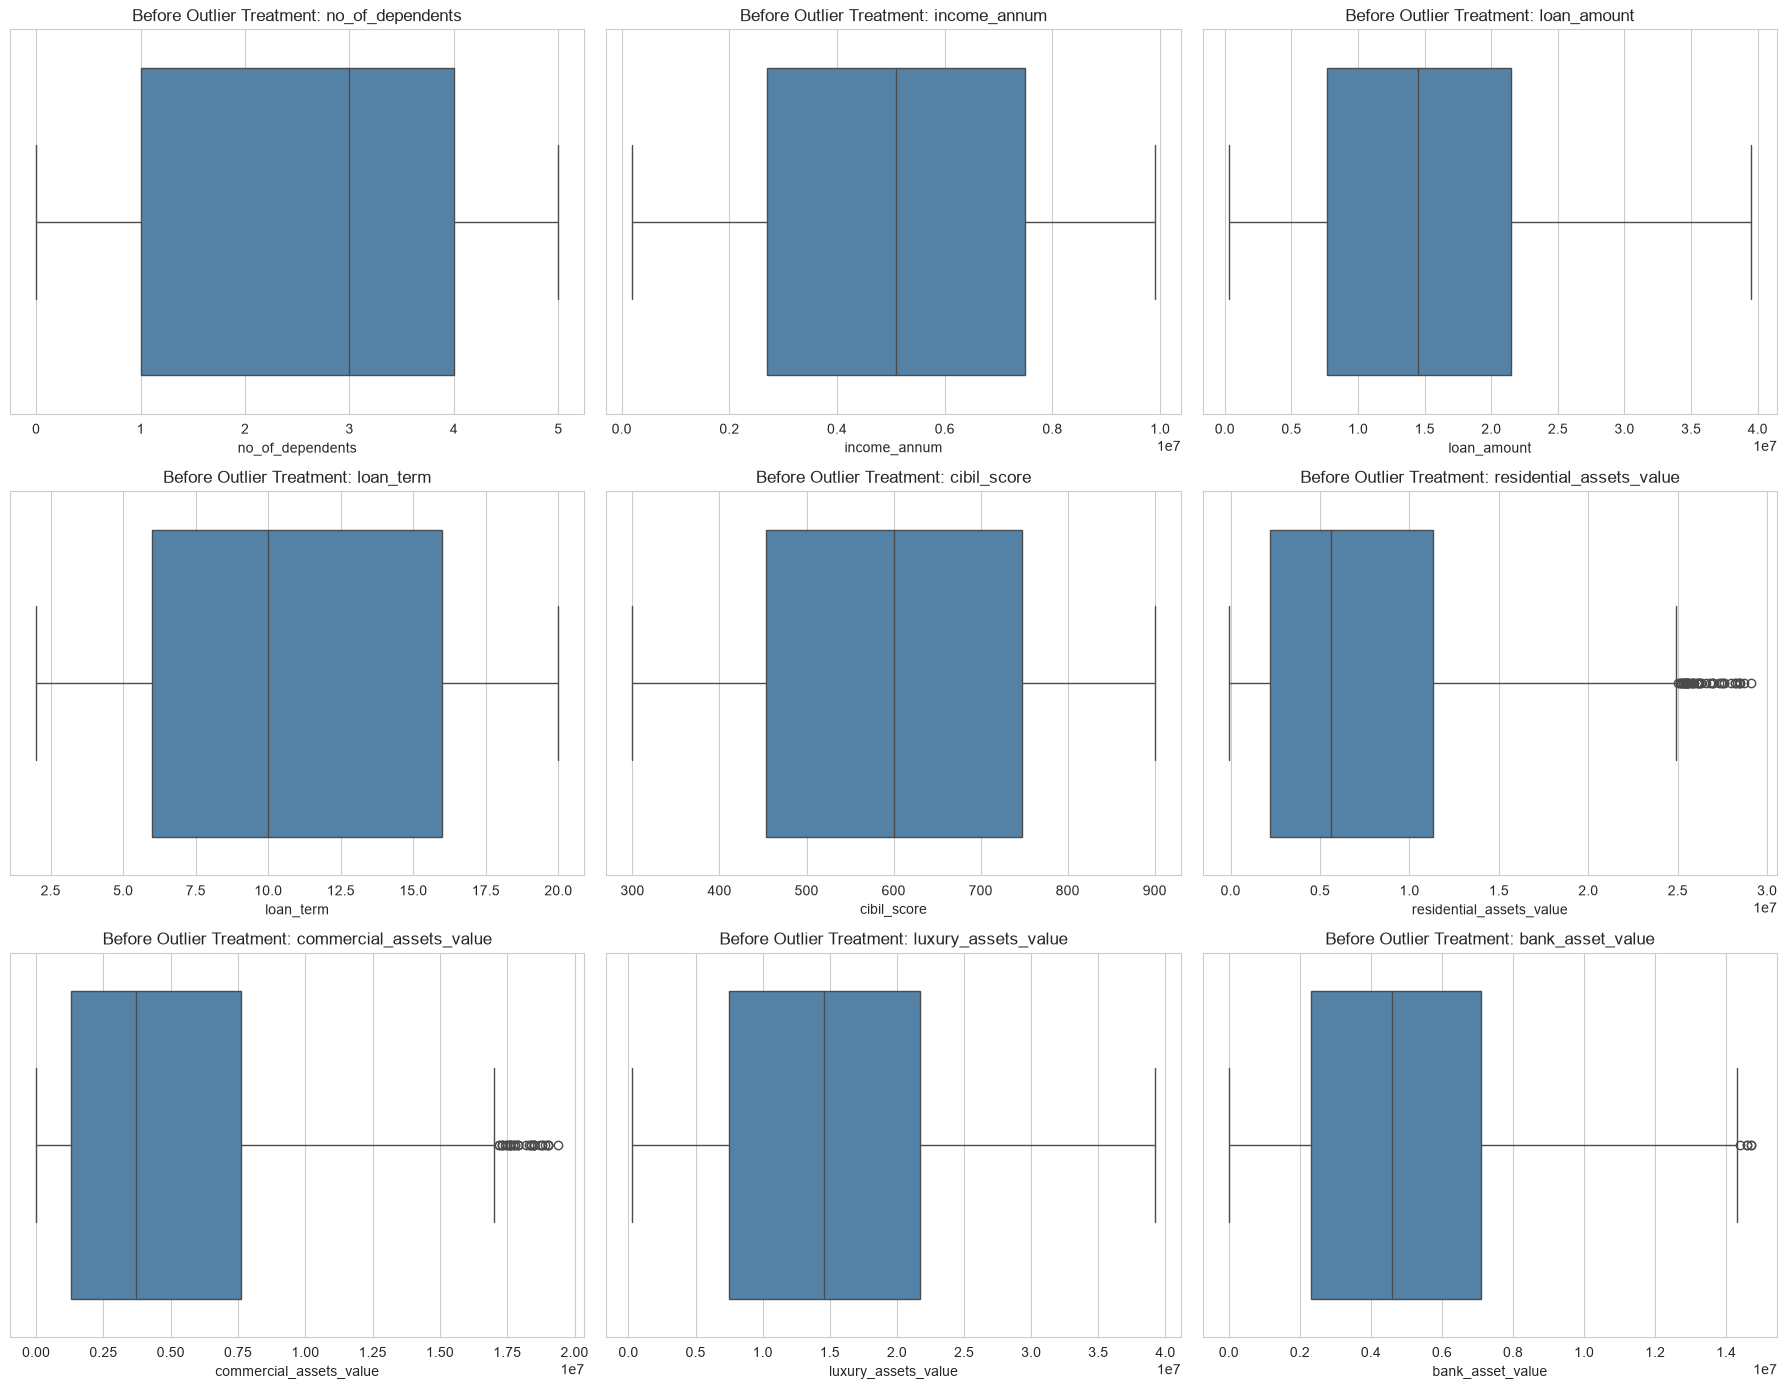


Outlier counts detected per column, prior to capping:
no_of_dependents: 0 outlier observations capped
income_annum: 0 outlier observations capped
loan_amount: 0 outlier observations capped
loan_term: 0 outlier observations capped
cibil_score: 0 outlier observations capped
residential_assets_value: 52 outlier observations capped
commercial_assets_value: 37 outlier observations capped
luxury_assets_value: 0 outlier observations capped
bank_asset_value: 5 outlier observations capped


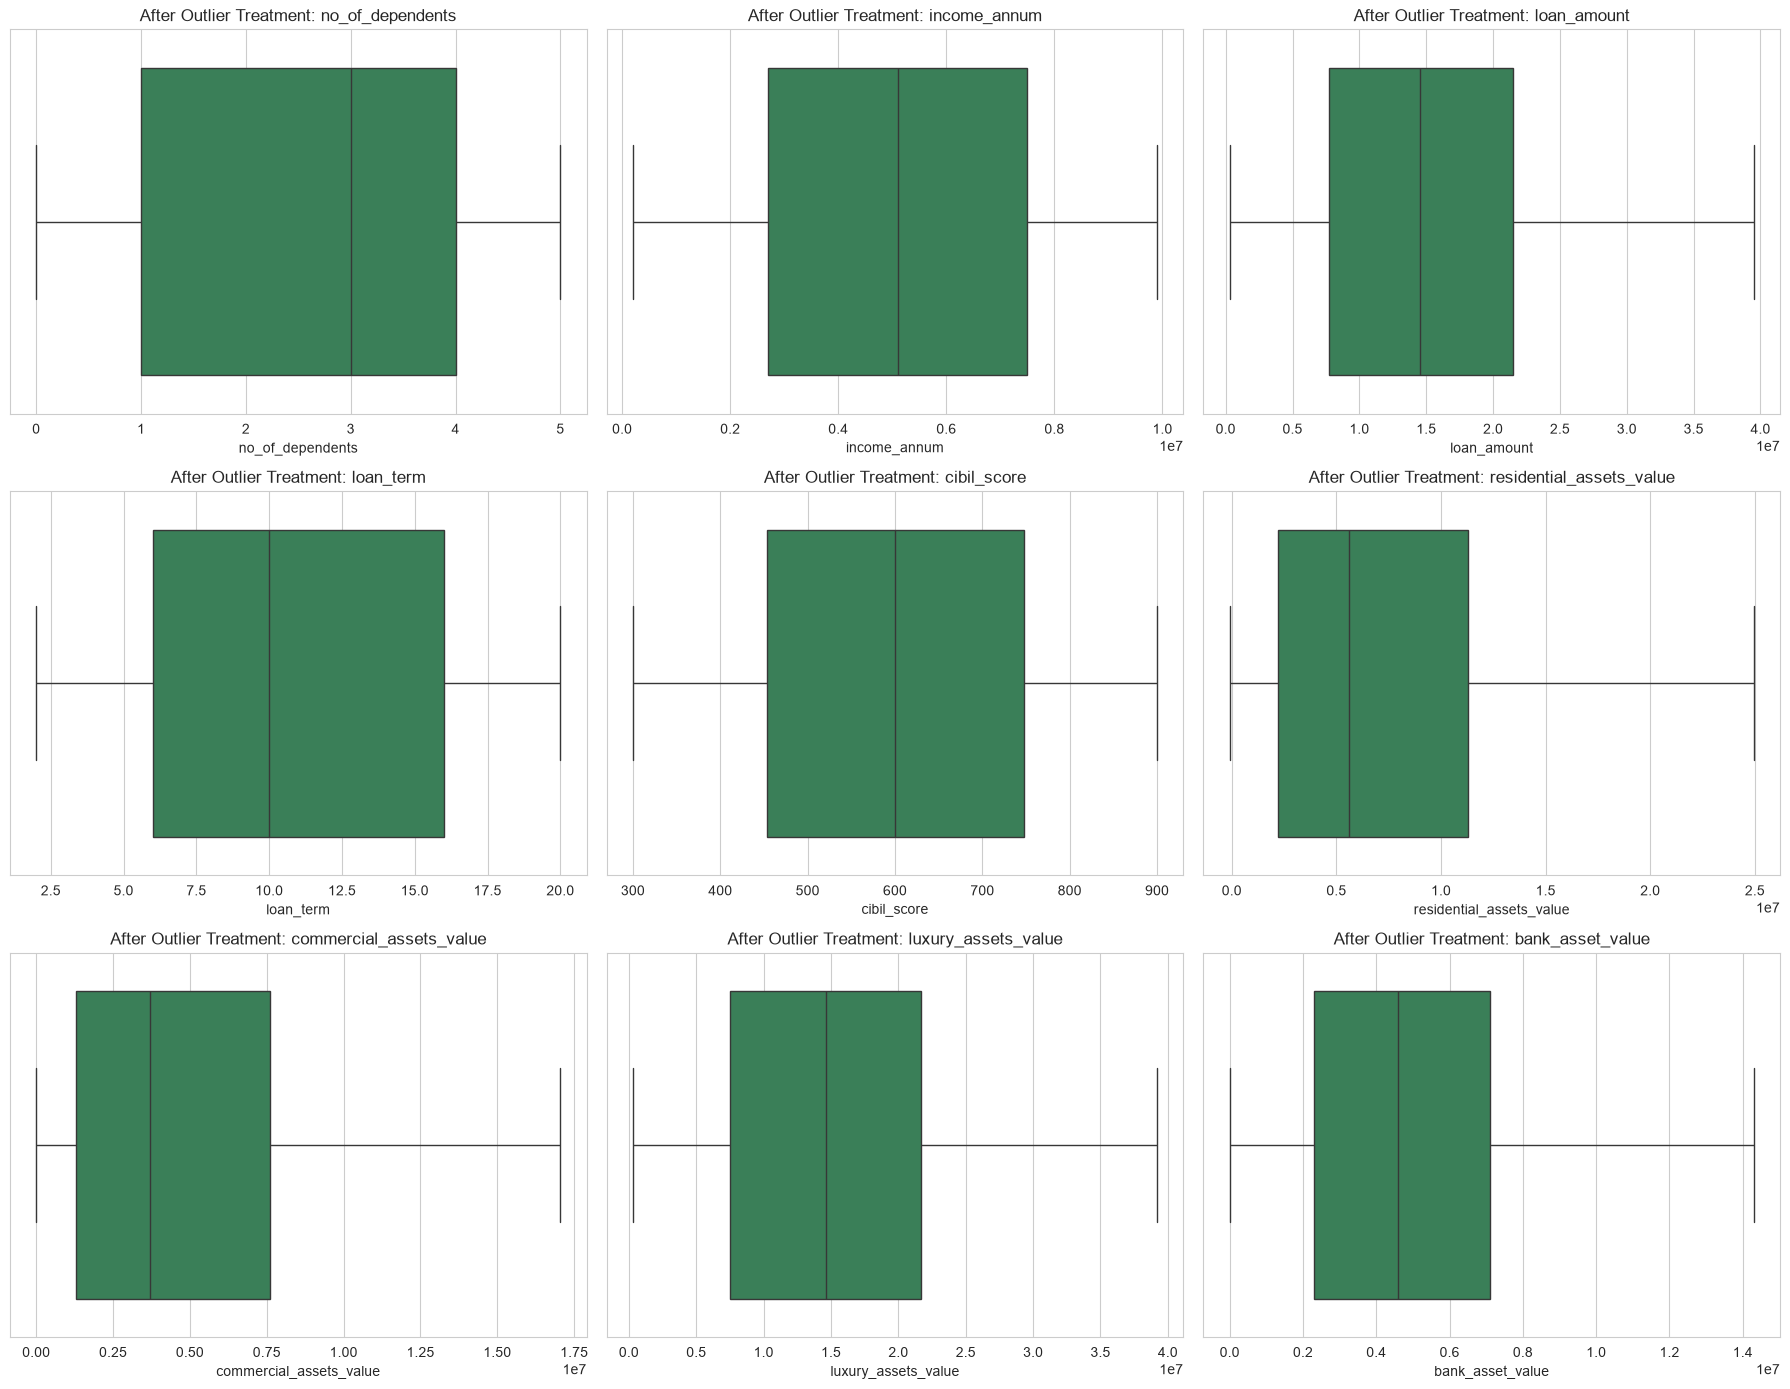

In [3]:
numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical columns considered for outlier treatment:")
print(numerical_columns)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for index, column in enumerate(numerical_columns):
    sns.boxplot(x=df[column], ax=axes[index], color="steelblue")
    axes[index].set_title(f"Before Outlier Treatment: {column}")
for extra_axis in axes[len(numerical_columns):]:
    extra_axis.axis("off")
plt.tight_layout()
plt.show()

outlier_summary = {}
for column in numerical_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers_detected = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    outlier_summary[column] = outliers_detected

    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

print()
print("Outlier counts detected per column, prior to capping:")
for column, count in outlier_summary.items():
    print(f"{column}: {count} outlier observations capped")

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for index, column in enumerate(numerical_columns):
    sns.boxplot(x=df[column], ax=axes[index], color="seagreen")
    axes[index].set_title(f"After Outlier Treatment: {column}")
for extra_axis in axes[len(numerical_columns):]:
    extra_axis.axis("off")
plt.tight_layout()
plt.show()

## Phase 5: Exploratory Data Analysis

Exploratory data analysis quantifies the distributional properties of the target variable
and its relationships with candidate predictors before any modeling decisions are made.
Univariate analysis of loan_amount reveals the overall scale and spread of the target,
while bivariate analysis against income_annum, cibil_score, and the asset value columns
reveals which predictors carry the strongest linear or non-linear association with the
target. A correlation heatmap summarizes pairwise linear relationships across all numerical
features, which is particularly informative for anticipating the relative performance of
the linear regression baseline compared to the non-linear tree-based ensembles.

Descriptive statistics for loan_amount (the regression target):
count    4.269000e+03
mean     1.513345e+07
std      9.043363e+06
min      3.000000e+05
25%      7.700000e+06
50%      1.450000e+07
75%      2.150000e+07
max      3.950000e+07
Name: loan_amount, dtype: float64


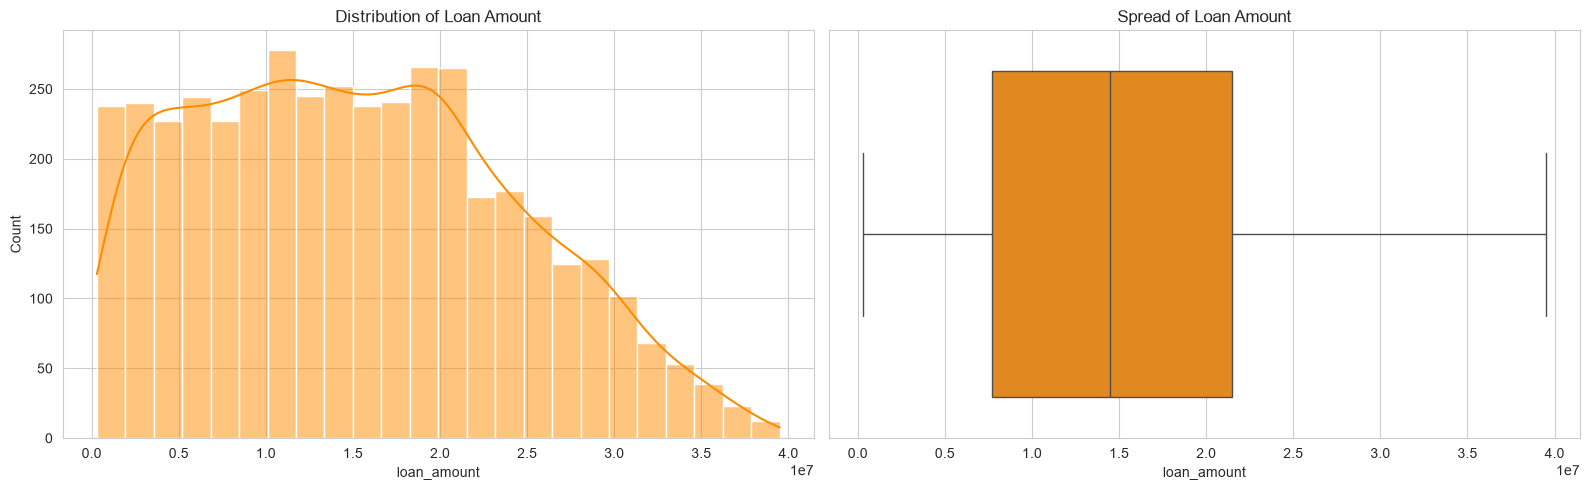


Summary statistics for all numerical features:


,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.454861e+06,4.964289e+06,1.512631e+07,4.976341e+06
std,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.452442e+06,4.363080e+06,9.103754e+06,3.249159e+06
min,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.495000e+07,1.705000e+07,3.920000e+07,1.430000e+07


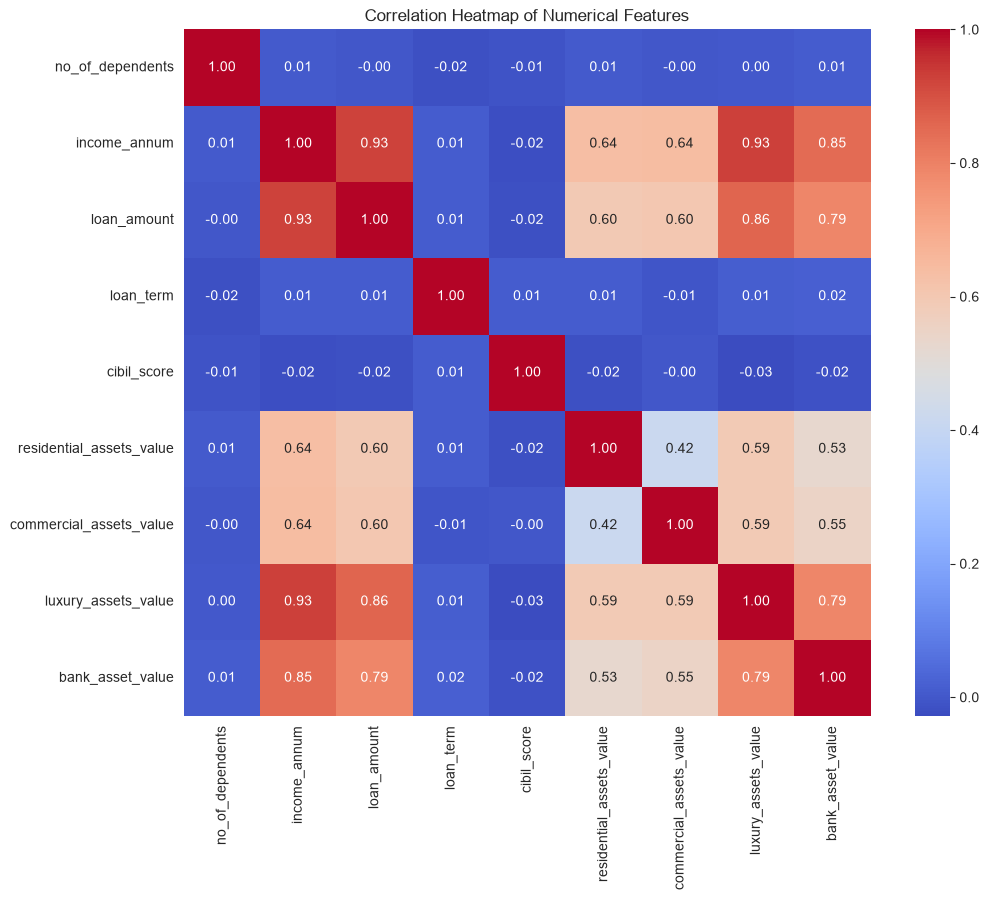

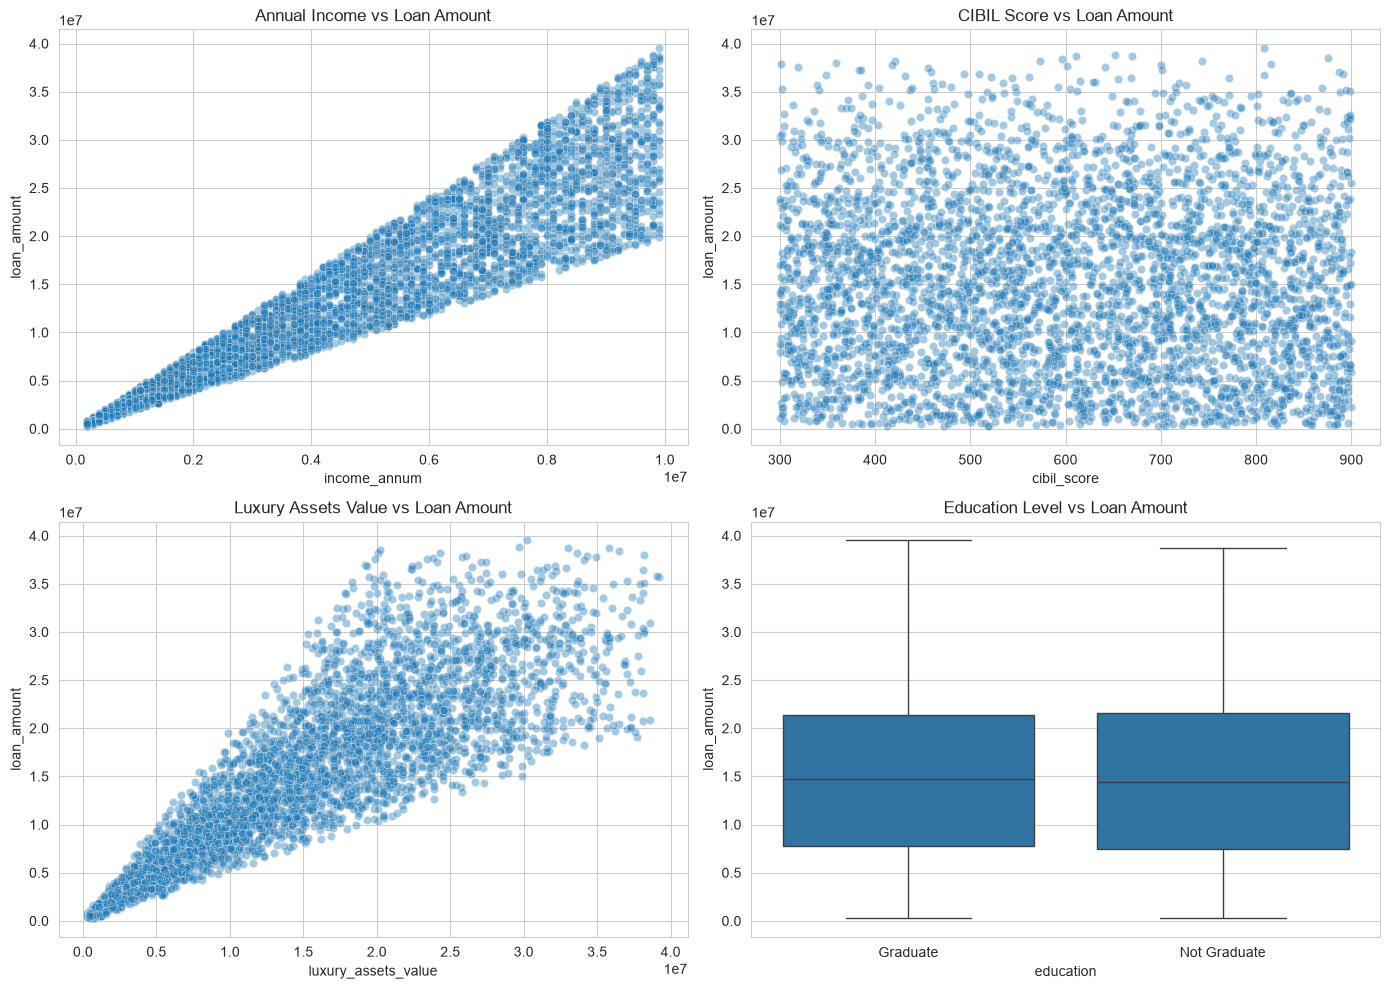

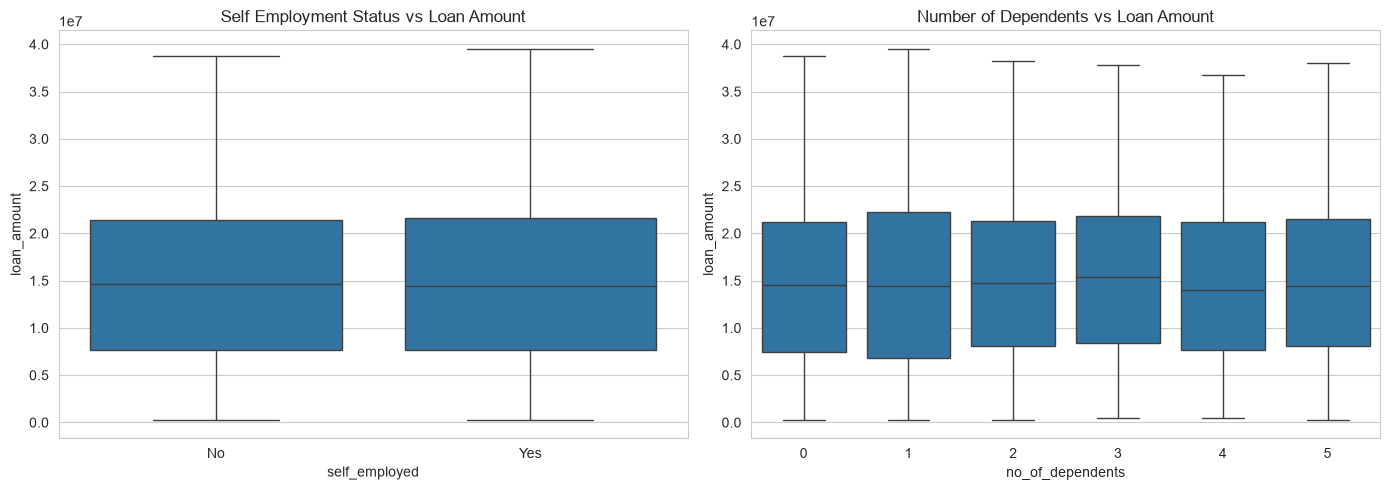

In [4]:
print("Descriptive statistics for loan_amount (the regression target):")
print(df["loan_amount"].describe())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df["loan_amount"], kde=True, ax=axes[0], color="darkorange")
axes[0].set_title("Distribution of Loan Amount")
sns.boxplot(x=df["loan_amount"], ax=axes[1], color="darkorange")
axes[1].set_title("Spread of Loan Amount")
plt.tight_layout()
plt.show()

print()
print("Summary statistics for all numerical features:")
display(df.describe())

correlation_matrix = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(11, 9))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.scatterplot(data=df, x="income_annum", y="loan_amount", ax=axes[0, 0], alpha=0.4)
axes[0, 0].set_title("Annual Income vs Loan Amount")
sns.scatterplot(data=df, x="cibil_score", y="loan_amount", ax=axes[0, 1], alpha=0.4)
axes[0, 1].set_title("CIBIL Score vs Loan Amount")
sns.scatterplot(data=df, x="luxury_assets_value", y="loan_amount", ax=axes[1, 0], alpha=0.4)
axes[1, 0].set_title("Luxury Assets Value vs Loan Amount")
sns.boxplot(data=df, x="education", y="loan_amount", ax=axes[1, 1])
axes[1, 1].set_title("Education Level vs Loan Amount")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="self_employed", y="loan_amount", ax=axes[0])
axes[0].set_title("Self Employment Status vs Loan Amount")
sns.boxplot(data=df, x="no_of_dependents", y="loan_amount", ax=axes[1])
axes[1].set_title("Number of Dependents vs Loan Amount")
plt.tight_layout()
plt.show()

## Phase 6: Data Preprocessing and Feature Engineering

Machine learning estimators in scikit-learn and xgboost require purely numerical input
matrices. The categorical columns education and self_employed must therefore be transformed
into a numerical representation through One-Hot Encoding, implemented via
pandas.get_dummies with drop_first equal to True to avoid perfect multicollinearity between
the encoded indicator columns. The loan_status column is deliberately excluded from the
feature matrix, consistent with the business justification given in Phase 1, since it
represents information that would not be available at the moment a loan amount
recommendation is required and would otherwise leak information about the target through
its historical association with approved amounts. The target vector y is defined as
loan_amount. The complete ordered list of resulting feature column names is captured in a
variable named feature_columns, which is later serialized alongside the trained model to
guarantee that inference-time feature alignment is exact.

In [5]:
TARGET_COLUMN = "loan_amount"

feature_source = df.drop(columns=[TARGET_COLUMN, "loan_status"])
y = df[TARGET_COLUMN].copy()

X = pd.get_dummies(feature_source, columns=["education", "self_employed"], drop_first=True)

feature_columns = X.columns.tolist()

print("Final feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print()
print("Feature columns used for modeling:")
print(feature_columns)
print()
print("Head of the encoded feature matrix:")
display(X.head())

Final feature matrix shape: (4269, 10)
Target vector shape: (4269,)

Feature columns used for modeling:
['no_of_dependents', 'income_annum', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'education_Not Graduate', 'self_employed_Yes']

Head of the encoded feature matrix:


,no_of_dependents,income_annum,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_Not Graduate,self_employed_Yes
0,2,9600000,12,778,2400000,17050000,22700000,8000000,False,False
1,0,4100000,8,417,2700000,2200000,8800000,3300000,True,True
2,3,9100000,20,506,7100000,4500000,33300000,12800000,False,False
3,3,8200000,8,467,18200000,3300000,23300000,7900000,False,False
4,5,9800000,20,382,12400000,8200000,29400000,5000000,True,True


## Phase 7: Train and Test Split, and Feature Scaling

The encoded feature matrix and the target vector are partitioned into an 80 percent
training subset and a 20 percent testing subset using a fixed random_state of 42 to ensure
reproducibility. Because loan_amount is a continuous quantity, stratification on the target
itself is not applicable in the same way it would be for a classification label; instead,
the split is performed uniformly at random over the full sample. Feature scaling through
StandardScaler is then applied. The scaler is fit exclusively on the training partition to
prevent information from the test partition from leaking into the transformation
parameters, and the fitted scaler is subsequently used to transform both the training and
testing feature matrices. While tree-based estimators such as Decision Tree, Random Forest,
and XGBoost are invariant to monotonic feature scaling, Linear Regression benefits from
standardized inputs for numerically stable coefficient estimation, and a single consistent
preprocessing pipeline is maintained across all four candidate models for methodological
consistency and simplified production deployment.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_columns, index=X_test.index)

print()
print("Feature scaling completed using StandardScaler fitted on the training partition.")

Training set shape: (3415, 10)
Testing set shape: (854, 10)

Feature scaling completed using StandardScaler fitted on the training partition.


## Phase 8: Model Training and Hyperparameter Tuning

Four regression algorithms are trained and tuned in this phase. Linear Regression has no
meaningful hyperparameters to tune under its ordinary least squares formulation and is
therefore fit directly on the scaled training data as a baseline. Decision Tree Regressor,
Random Forest Regressor, and XGBoost Regressor are each tuned using GridSearchCV with 5
fold cross validation, optimizing for the R-squared scoring metric. Grid search
systematically evaluates every combination of the specified hyperparameter values,
controlling tree depth, minimum samples required to split or form a leaf node, and, for the
ensemble methods, the number of estimators and learning rate, in order to identify the
configuration that generalizes best across cross validation folds rather than the
configuration that merely memorizes the training data.

In [7]:
trained_models = {}
best_params = {}
cv_scores = {}

# ---- Linear Regression (baseline, no hyperparameter search required) ----
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
trained_models["Linear Regression"] = linear_model
best_params["Linear Regression"] = "Ordinary Least Squares (no tunable hyperparameters)"
print("Linear Regression training completed.")

# ---- Decision Tree Regressor ----
dt_param_grid = {
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
}
dt_grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid=dt_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
dt_grid_search.fit(X_train_scaled, y_train)
trained_models["Decision Tree"] = dt_grid_search.best_estimator_
best_params["Decision Tree"] = dt_grid_search.best_params_
cv_scores["Decision Tree"] = dt_grid_search.best_score_
print("Decision Tree Regressor tuning completed.")
print("Best parameters:", dt_grid_search.best_params_)
print("Best cross validation R-squared:", dt_grid_search.best_score_)

# ---- Random Forest Regressor ----
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
}
rf_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid=rf_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
rf_grid_search.fit(X_train_scaled, y_train)
trained_models["Random Forest"] = rf_grid_search.best_estimator_
best_params["Random Forest"] = rf_grid_search.best_params_
cv_scores["Random Forest"] = rf_grid_search.best_score_
print("Random Forest Regressor tuning completed.")
print("Best parameters:", rf_grid_search.best_params_)
print("Best cross validation R-squared:", rf_grid_search.best_score_)

# ---- XGBoost Regressor ----
if XGBOOST_AVAILABLE:
    xgb_param_grid = {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 4, 5, 6],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.8, 1.0],
    }
    xgb_grid_search = GridSearchCV(
        estimator=XGBRegressor(random_state=RANDOM_STATE, objective="reg:squarederror"),
        param_grid=xgb_param_grid,
        cv=5,
        scoring="r2",
        n_jobs=-1,
    )
    xgb_grid_search.fit(X_train_scaled, y_train)
    trained_models["XGBoost"] = xgb_grid_search.best_estimator_
    best_params["XGBoost"] = xgb_grid_search.best_params_
    cv_scores["XGBoost"] = xgb_grid_search.best_score_
    print("XGBoost Regressor tuning completed.")
    print("Best parameters:", xgb_grid_search.best_params_)
    print("Best cross validation R-squared:", xgb_grid_search.best_score_)
else:
    print("XGBoost is not available in this environment; skipping XGBoost training.")
    print("Install xgboost and re-run this cell to include it in the comparison.")

Linear Regression training completed.
Decision Tree Regressor tuning completed.
Best parameters: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross validation R-squared: 0.8564683344823759
Random Forest Regressor tuning completed.
Best parameters: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 300}
Best cross validation R-squared: 0.8595479890390196
XGBoost Regressor tuning completed.
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best cross validation R-squared: 0.8599726915359497


## Phase 9: Model Evaluation and Comparative Analysis

A regression model cannot be adequately judged by a single metric. R-squared quantifies the
proportion of variance in the target explained by the model, but it does not communicate
the error in the original monetary units. Mean Absolute Error reports the average absolute
deviation between predicted and actual loan amounts in the same units as the target, Mean
Squared Error penalizes larger errors more heavily due to squaring, Root Mean Squared Error
restores the original units while retaining sensitivity to large errors, and Mean Absolute
Percentage Error expresses the average error as a percentage of the true value, which
supports comparison across differently scaled targets. All four trained models are
evaluated on the held-out test partition using this complete set of metrics, and the
results are consolidated into a single comparison table for direct inspection.

In [8]:
evaluation_results = []

for model_name, model in trained_models.items():
    predictions = model.predict(X_test_scaled)

    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, predictions)

    evaluation_results.append(
        {
            "Model": model_name,
            "R2 Score": r2,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "MAPE": mape,
        }
    )

    print(f"Model: {model_name}")
    print(f"  R2 Score : {r2:.4f}")
    print(f"  MAE      : {mae:,.2f}")
    print(f"  MSE      : {mse:,.2f}")
    print(f"  RMSE     : {rmse:,.2f}")
    print(f"  MAPE     : {mape:.4f}")
    print()

comparison_df = pd.DataFrame(evaluation_results).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)
print("Consolidated model comparison table, sorted by R2 Score:")
display(comparison_df)

Model: Linear Regression
  R2 Score : 0.8514
  MAE      : 2,626,187.69
  MSE      : 11,915,005,361,676.34
  RMSE     : 3,451,811.90
  MAPE     : 0.1888

Model: Decision Tree
  R2 Score : 0.8480
  MAE      : 2,663,017.88
  MSE      : 12,184,436,331,482.05
  RMSE     : 3,490,621.20
  MAPE     : 0.2086

Model: Random Forest
  R2 Score : 0.8523
  MAE      : 2,608,638.86
  MSE      : 11,842,509,003,969.32
  RMSE     : 3,441,294.67
  MAPE     : 0.1920

Model: XGBoost
  R2 Score : 0.8529
  MAE      : 2,612,951.50
  MSE      : 11,794,883,018,752.00
  RMSE     : 3,434,367.92
  MAPE     : 0.2035

Consolidated model comparison table, sorted by R2 Score:


,Model,R2 Score,MAE,MSE,RMSE,MAPE
0,XGBoost,0.852904,2.612952e+06,1.179488e+13,3.434368e+06,0.203494
1,Random Forest,0.852310,2.608639e+06,1.184251e+13,3.441295e+06,0.191950
2,Linear Regression,0.851406,2.626188e+06,1.191501e+13,3.451812e+06,0.188761
3,Decision Tree,0.848046,2.663018e+06,1.218444e+13,3.490621e+06,0.208580


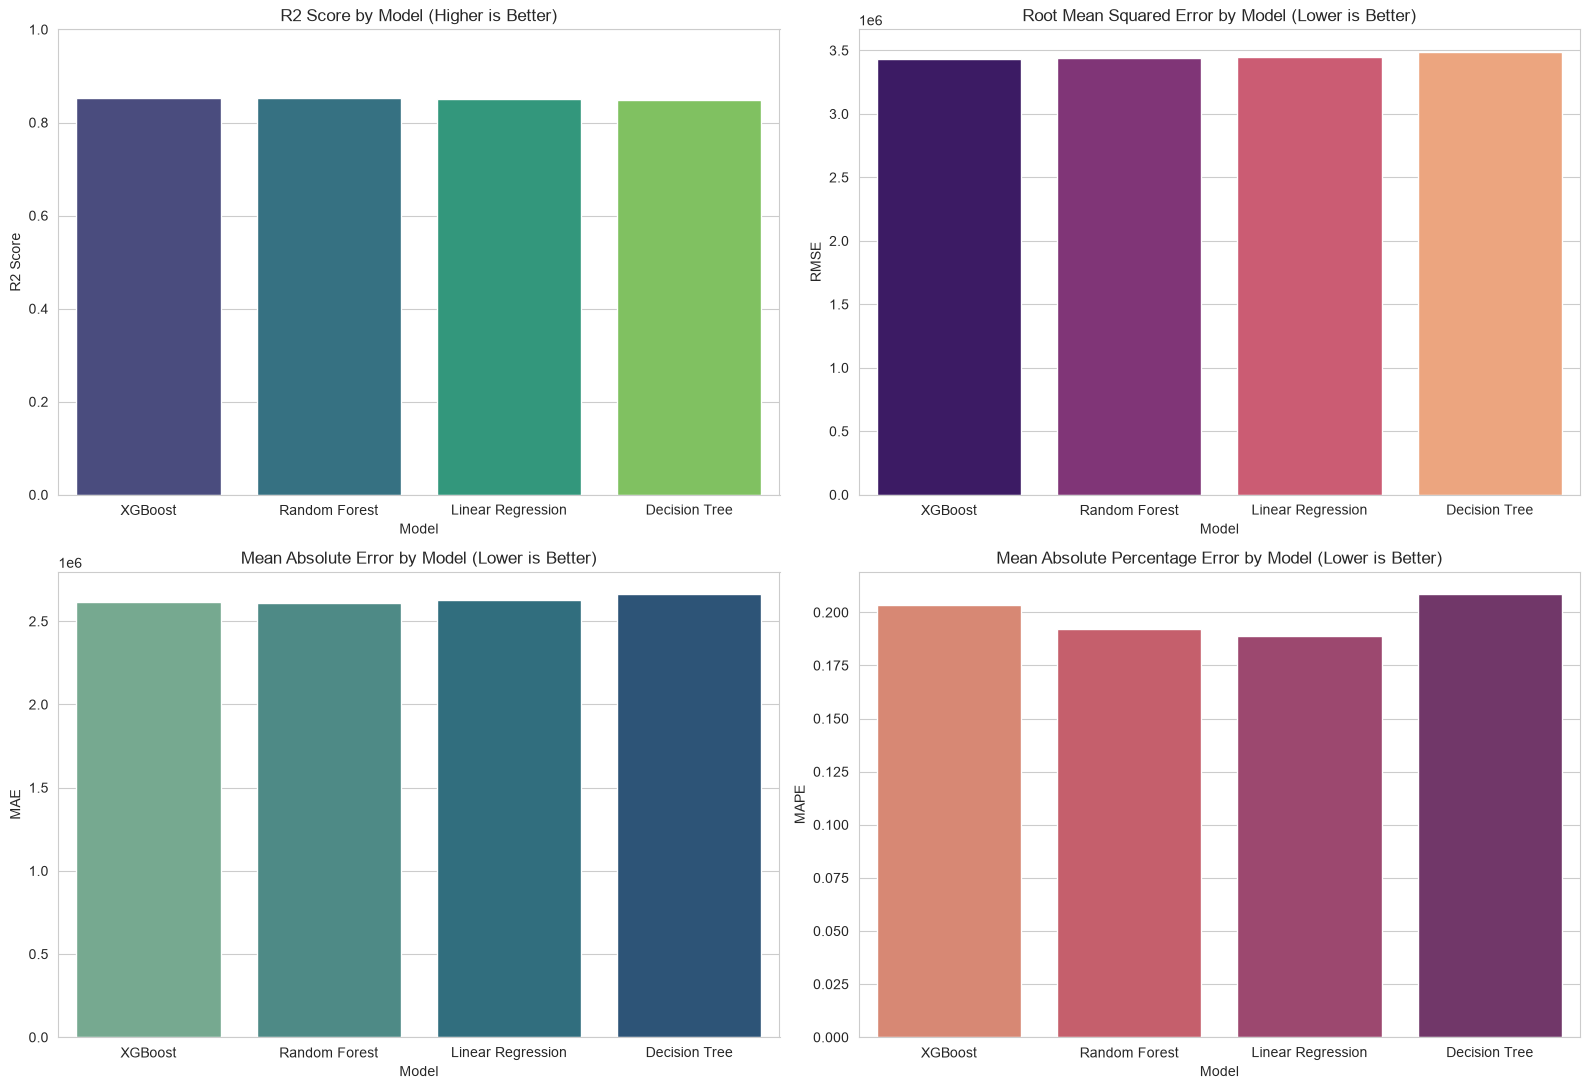

Best performing model based on test set R2 Score: XGBoost
Model                XGBoost
R2 Score            0.852904
MAE                2612951.5
MSE         11794883018752.0
RMSE          3434367.921285
MAPE                0.203494
Name: 0, dtype: object


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.barplot(data=comparison_df, x="Model", y="R2 Score", ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("R2 Score by Model (Higher is Better)")
axes[0, 0].set_ylim(0, 1)

sns.barplot(data=comparison_df, x="Model", y="RMSE", ax=axes[0, 1], palette="magma")
axes[0, 1].set_title("Root Mean Squared Error by Model (Lower is Better)")

sns.barplot(data=comparison_df, x="Model", y="MAE", ax=axes[1, 0], palette="crest")
axes[1, 0].set_title("Mean Absolute Error by Model (Lower is Better)")

sns.barplot(data=comparison_df, x="Model", y="MAPE", ax=axes[1, 1], palette="flare")
axes[1, 1].set_title("Mean Absolute Percentage Error by Model (Lower is Better)")

plt.tight_layout()
plt.show()

best_model_name = comparison_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"Best performing model based on test set R2 Score: {best_model_name}")
print(comparison_df.iloc[0])

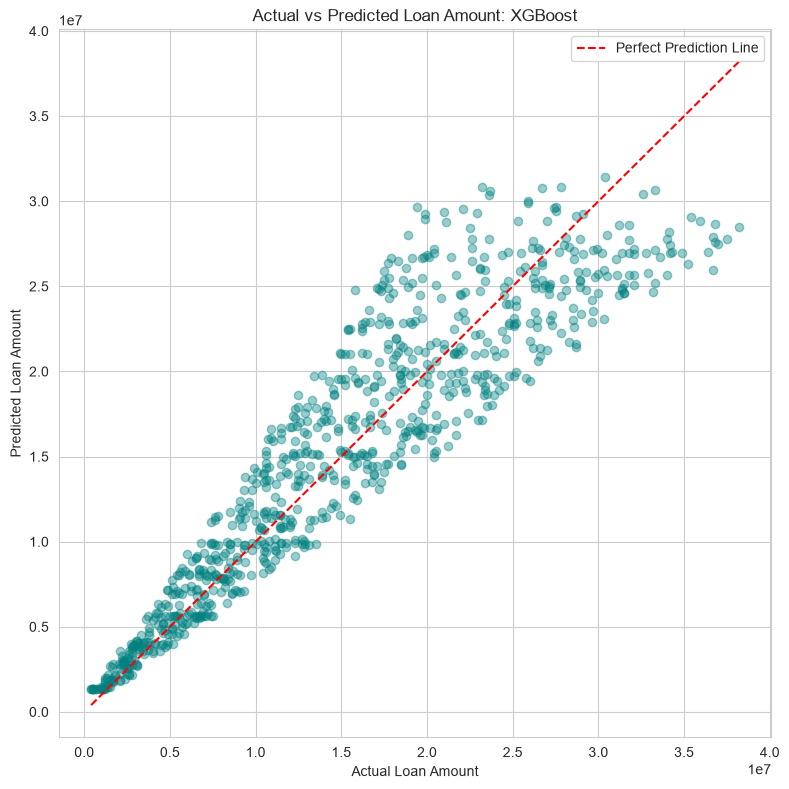

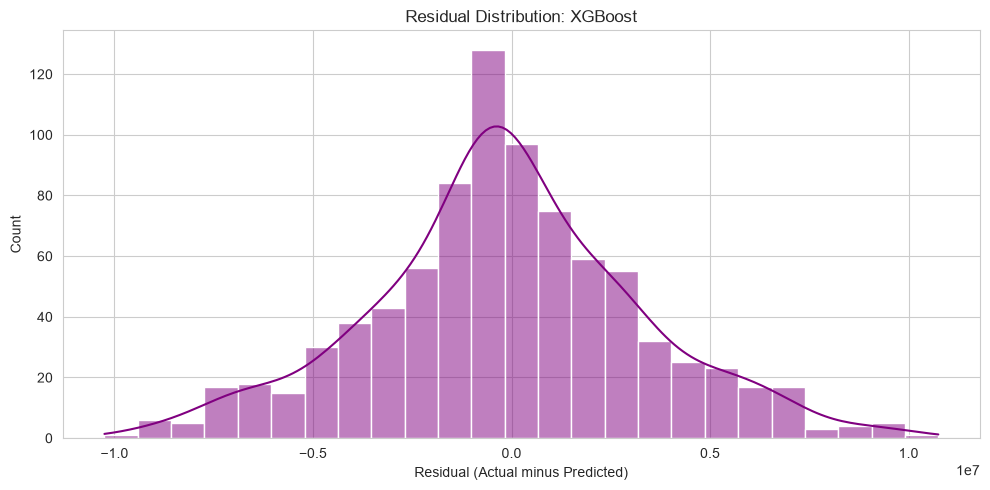

In [10]:
best_predictions = best_model.predict(X_test_scaled)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_predictions, alpha=0.4, color="teal")
min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())
plt.plot([min_value, max_value], [min_value, max_value], color="red", linestyle="--", label="Perfect Prediction Line")
plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title(f"Actual vs Predicted Loan Amount: {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

residuals = y_test - best_predictions
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color="purple")
plt.title(f"Residual Distribution: {best_model_name}")
plt.xlabel("Residual (Actual minus Predicted)")
plt.tight_layout()
plt.show()

## Phase 10: Best Model Selection Justification

The model selected for production deployment is the one that achieves the highest
R-squared score on the held-out test partition, subject to confirmation that its error
metrics, MAE, RMSE, and MAPE, are consistent with, and do not contradict, the R-squared
ranking. Ensemble tree-based methods, Random Forest and XGBoost, are generally expected to
outperform a single Decision Tree due to variance reduction through aggregation, and are
generally expected to outperform Linear Regression whenever the true relationship between
applicant attributes and loan amount contains non-linear interactions, for example between
income and asset values. The model identified as best_model_name in the previous phase is
the one carried forward into the serialization and deployment phases below.

## Phase 11: Model Serialization and Deployment Artifact Export

Model persistence decouples the training pipeline, executed once in this notebook, from
the production inference pipeline, executed repeatedly inside the Streamlit web
application. Three artifacts are required for correct and reproducible inference: the
trained regression model selected in Phase 10, the fitted StandardScaler instance used to
transform raw applicant attributes into the scale expected by the model, and the exact
ordered list of feature column names, feature_columns, which guarantees that the
one-hot-encoded columns constructed at inference time are aligned identically to the
columns seen during training. A metadata artifact recording the model comparison results
and the identity of the selected model is also exported to support downstream auditing and
reporting. Robust directory creation logic ensures that the models directory exists whether
this notebook is executed from the notebooks directory or from the project root.

In [11]:
model_directory_candidates = [os.path.join("..", "models"), "models"]
MODEL_DIRECTORY = None
for candidate in model_directory_candidates:
    parent = os.path.dirname(candidate) or "."
    if os.path.isdir(parent) or candidate == "models":
        MODEL_DIRECTORY = candidate
        break

if MODEL_DIRECTORY is None:
    MODEL_DIRECTORY = "models"

os.makedirs(MODEL_DIRECTORY, exist_ok=True)
print("Model artifacts will be saved to:", os.path.abspath(MODEL_DIRECTORY))

model_path = os.path.join(MODEL_DIRECTORY, "loan_amount_regression_model.joblib")
scaler_path = os.path.join(MODEL_DIRECTORY, "standard_scaler.joblib")
feature_columns_path = os.path.join(MODEL_DIRECTORY, "feature_columns.joblib")
metadata_path = os.path.join(MODEL_DIRECTORY, "loan_amount_model_metadata.joblib")

joblib.dump(best_model, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(feature_columns, feature_columns_path)

metadata = {
    "best_model_name": best_model_name,
    "target_column": TARGET_COLUMN,
    "feature_columns": feature_columns,
    "comparison_table": comparison_df.to_dict(orient="records"),
    "best_params": best_params.get(best_model_name, {}),
}
joblib.dump(metadata, metadata_path)

print("Saved trained regression model to:", model_path)
print("Saved fitted StandardScaler to:", scaler_path)
print("Saved feature column ordering to:", feature_columns_path)
print("Saved model metadata to:", metadata_path)

reports_directory_candidates = [os.path.join("..", "reports", "figures"), os.path.join("reports", "figures")]
REPORTS_DIRECTORY = None
for candidate in reports_directory_candidates:
    parent = os.path.dirname(os.path.dirname(candidate)) or "."
    if os.path.isdir(parent) or candidate.startswith("reports"):
        REPORTS_DIRECTORY = candidate
        break

if REPORTS_DIRECTORY is None:
    REPORTS_DIRECTORY = os.path.join("reports", "figures")

os.makedirs(REPORTS_DIRECTORY, exist_ok=True)
comparison_export_path = os.path.join(REPORTS_DIRECTORY, "regression_model_comparison.csv")
comparison_df.to_csv(comparison_export_path, index=False)
print("Saved model comparison table to:", comparison_export_path)

Model artifacts will be saved to: c:\Users\soham\Desktop\ahmed\NTI-ML\Regression\LoanAmount_Regression_Project\models
Saved trained regression model to: ..\models\loan_amount_regression_model.joblib
Saved fitted StandardScaler to: ..\models\standard_scaler.joblib
Saved feature column ordering to: ..\models\feature_columns.joblib
Saved model metadata to: ..\models\loan_amount_model_metadata.joblib
Saved model comparison table to: ..\reports\figures\regression_model_comparison.csv


## Phase 12: Conclusion and Next Steps

This notebook implemented a complete, end-to-end regression pipeline for estimating loan
amounts from applicant attributes, encompassing business framing, data ingestion, quality
assessment, outlier treatment, exploratory analysis, feature engineering, model training
with cross-validated hyperparameter tuning, multi-metric evaluation, and artifact
serialization. The best performing model identified through this process has been exported
alongside its fitted scaler and feature schema, and is now ready to be consumed by the
accompanying Streamlit application, streamlit_app.py, located in the app directory of this
project, which exposes an interactive interface for generating real-time loan amount
predictions from user-supplied applicant attributes. Recommended future work includes
periodic retraining as new application data becomes available, monitoring for distribution
drift in applicant attributes, and extending the feature set with additional applicant
attributes should they become available.